# ClimX Getting Started (Colab-first)

<a target="_blank" href="https://colab.research.google.com/github/WinterSchool2026/ch06-mini-climate-emulation/blob/main/getting_started.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

This notebook is a quick starter for the mini challenge.

It mirrors the original playground flow:
1. Environment setup
2. Data download and loading
3. Preprocessing
4. Quick diagnostics
5. Tiny baseline training

## 0) Optional in fresh Colab

If you opened a blank Colab notebook, run this first.
If you opened this notebook from your repo, skip this cell.

In [1]:
# Install dependencies (safe to re-run)
!pip -q install -r requirements-colab.txt

In [2]:
import os
from pathlib import Path

os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.logging_utils import setup_logger, logging
from src.utils.hugging_face_utils import get_dataset_from_hf, open_climx_virtual_datasets
from src.data_preprocessing.preprocessing import preprocess_train
from src.visualization.visualize_data import plot_dataset_histograms

setup_logger(logging.INFO)

plt.style.use("ggplot")
sns.set_context("notebook", font_scale=1.1)
plt.rcParams["figure.figsize"] = [10, 6]
xr.set_options(display_width=180, display_max_rows=120)

DATA_VERSION = "lite"
data_path = Path("data/")
preprocessing_path = Path(f"preprocessing_data_{DATA_VERSION}/")
plot_stuff = False

2026-03-09 17:48:30,728 - root - INFO - Logger configured with level: INFO


/home/nate/anaconda3/envs/clima_emu_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download lite dataset (~500MB) if needed, then open virtual datasets
if Path(data_path).exists():
    logging.info(f"Data path {data_path} already exists. Skipping download.")
else:   
    get_dataset_from_hf(data_path, variant=DATA_VERSION)
    
dataset = open_climx_virtual_datasets(data_path, DATA_VERSION)

print(dataset)

2026-03-09 17:48:30,734 - root - INFO - Data path data already exists. Skipping download.
ClimXVirtualDatasets(hist=<xarray.Dataset> Size: 516GB
Dimensions:           (time: 60224, forcing_scenario: 1, time_month: 1980, lat: 12, lon: 18, time_year: 165)
Coordinates:
  * forcing_scenario  (forcing_scenario) <U10 40B 'historical'
  * lat               (lat) float64 96B -82.93 -67.85 -52.77 -37.7 -22.62 -7.539 7.539 22.62 37.7 52.77 67.85 82.93
  * lon               (lon) float64 144B 9.375 29.38 49.38 69.38 89.38 109.4 129.4 149.4 169.4 189.4 209.4 229.4 249.4 269.4 289.4 309.4 329.4 349.4
  * time              (time) object 482kB 1850-01-01 12:00:00 1850-01-02 12:00:00 1850-01-03 12:00:00 ... 2014-12-28 12:00:00 2014-12-29 12:00:00 2014-12-30 12:00:00
  * time_month        (time_month) object 16kB 1850-01-17 00:00:00 1850-02-17 00:00:00 1850-03-17 00:00:00 ... 2014-10-18 00:00:00 2014-11-18 00:00:00 2014-12-18 00:00:00
  * time_year         (time_year) object 1kB 1850-07-02 12:00:00 185

In [4]:
# Preprocess training data (uses same preprocessing flow as original playground)

if Path(f'preprocessing_data_{DATA_VERSION}/X_train.nc').exists() and Path(f'preprocessing_data_{DATA_VERSION}/y_train.nc').exists():
    logging.info("Preprocessed data already exists. Loading from disk...")
    X_train = xr.open_dataset(f'preprocessing_data_{DATA_VERSION}/X_train.nc')
    y_train = xr.open_dataset(f'preprocessing_data_{DATA_VERSION}/y_train.nc')
else:

    X_train, y_train, metadata = preprocess_train(
        dataset,
        preprocessing_path=preprocessing_path,
        version=DATA_VERSION,
        scaling_params_path=None,
    )

    X_train = X_train.chunk({'time': 30, 'lat': -1, 'lon': -1})
    X_train.to_netcdf(f'preprocessing_data_{DATA_VERSION}/X_train.nc')
    y_train = y_train.chunk({'time': 30, 'lat': -1, 'lon': -1})
    y_train.to_netcdf(f'preprocessing_data_{DATA_VERSION}/y_train.nc')


print("X_train dims:", dict(X_train.sizes))
print("y_train dims:", dict(y_train.sizes))

2026-03-09 17:48:31,875 - root - INFO - Preprocessed data already exists. Loading from disk...
X_train dims: {'forcing_scenario': 3, 'time': 31389, 'lat': 12, 'lon': 18}
y_train dims: {'forcing_scenario': 3, 'time': 31389, 'lat': 12, 'lon': 18}


In [5]:
# Quick distribution diagnostics
if plot_stuff:
    plot_dataset_histograms(X_train, 'Inputs')
    plot_dataset_histograms(y_train, 'Outputs')

In [6]:
# Split into training (ssp126, ssp370) and validation (ssp585)
X_v = X_train.sel(forcing_scenario=['ssp585'])
y_v = y_train.sel(forcing_scenario=['ssp585'])

X_t = X_train.sel(forcing_scenario=['ssp126','ssp370'])
y_t = y_train.sel(forcing_scenario=['ssp126','ssp370'])

In [7]:
# choose a model type and train it here, then load the predictions into pred_ds
model_type = 'lps' # 'lps', 'nn'

In [8]:
if model_type == 'nn':
    # Tiny NN baseline training for workshop timing
    from src.models.nn_model import NNBaseline
    import torch

    model_path = Path(f"models_{DATA_VERSION}") / "nn"

    model_params = {
        "n_lat": 192,
        "n_lon": 288,
        "n_forcing_vars": len(list(X_train.data_vars)),
        "n_target_vars": len(list(y_train.data_vars)),
        "learning_rate": 1e-3,
        "separate_output_heads": True,
    }

    emulator = NNBaseline(model_params)

    if model_path.exists():
        logging.info(f"Model path {model_path} already exists. Skipping model training.")

        emulator.load(model_path)
    else:
        torch.manual_seed(42)
        
        trainer_params = {"max_epochs": 2, "model_path": model_path}

        emulator = NNBaseline(model_params)

        emulator.fit(X_t, y_t, trainer_params=trainer_params)

        emulator.save(model_path)

        emulator.plot_loss()
elif model_type == 'lps':
    from src.models.lps_model import LPSBaseline

    model_path = Path(f"models_{DATA_VERSION}") / "lps"

    emulator = LPSBaseline()

    if model_path.exists():
        logging.info(f"Model path {model_path} already exists. Skipping model training.")

        emulator.load(model_path)
    else:
        emulator.fit(X_t, y_t)

        emulator.save(model_path)


2026-03-09 17:48:34,124 - pint.util - WARNING - Redefining 'percent' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-03-09 17:48:34,124 - pint.util - WARNING - Redefining '%' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-03-09 17:48:34,125 - pint.util - WARNING - Redefining 'year' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-03-09 17:48:34,125 - pint.util - WARNING - Redefining 'yr' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-03-09 17:48:34,126 - pint.util - WARNING - Redefining 'C' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-03-09 17:48:34,126 - pint.util - WARNING - Redefining 'd' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-03-09 17:48:34,127 - pint.util - WARNING - Redefining 'h' (<class 'pint.delegates.txt_defparser.plain.UnitDefinition'>)
2026-03-09 17:48:34,127 - pint.util - WARNING - Redefining 'degrees_north' (<class 'pint.delegates.txt_defparser.pl

In [9]:
import json

metadata_test = {
    'climatology_path': str(preprocessing_path / f'climatology_{DATA_VERSION}.nc'),
    'scaling_params_path': str(preprocessing_path / f'scaling_params_{DATA_VERSION}.json'),
    'scaling_params': json.load(open(preprocessing_path / f'scaling_parameters_{DATA_VERSION}.json')),
    'stationarization_mode': 'monthly',
}

results_path = Path(f"results_{DATA_VERSION}")
predictions_path = Path(f"predictions_{DATA_VERSION}")
TARGET_VARIABLES = ['huss', 'pr', 'psl', 'sfcWind', 'tas', 'tasmax', 'tasmin']

y_pred, indices_pred = emulator.evaluate(
    X_v.isel(forcing_scenario=0, drop=True), 
    metadata_test, 
    results_path, 
    predictions_path,
    dataset.hist, 
    TARGET_VARIABLES=TARGET_VARIABLES,
    LOAD_PREDICTIONS=False,
    compute_indices=True,
 )

2026-03-09 17:48:35,284 - src.models.emulator - INFO - Making predictions...
2026-03-09 17:48:35,285 - src.models.lps_model - INFO - Predicting climate variable(s) from CO2 input...
2026-03-09 17:48:35,300 - root - WARNING - target_vars not set, defaulting to ['tas', 'tasmax', 'tasmin', 'pr', 'huss', 'psl', 'sfcWind'] variables
2026-03-09 17:48:35,349 - src.models.emulator - INFO - Reversing preprocessing for predictions...
2026-03-09 17:48:35,367 - src.data_preprocessing.preprocessing_utils - INFO - Unscaled huss using standardize method
2026-03-09 17:48:35,386 - src.data_preprocessing.preprocessing_utils - INFO - Unscaled pr using standardize method
2026-03-09 17:48:35,401 - src.data_preprocessing.preprocessing_utils - INFO - Unscaled psl using standardize method
2026-03-09 17:48:35,415 - src.data_preprocessing.preprocessing_utils - INFO - Unscaled sfcWind using standardize method
2026-03-09 17:48:35,431 - src.data_preprocessing.preprocessing_utils - INFO - Unscaled tas using standar

Indices: R10mm: 100%|██████████| 15/15 [00:21<00:00,  1.46s/it] 


/home/nate/anaconda3/envs/clima_emu_new/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/nate/anaconda3/envs/clima_emu_new/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/nate/anaconda3/envs/clima_emu_new/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: divide by zero encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/nate/anaconda3/envs/clima_emu_new/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/nate/anaconda3/envs/clima_emu_new/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in divide
  return func(*(_execute_task(a, cache) for a in args))
/home/nate/anaconda3/en

In [10]:
import inspect
from src.utils.indices_utils import load_indices, format_indices

raw_data_path = Path(f'/home/nate/Documents/ch06-mini-climate-emulation/data/{DATA_VERSION}/')  # Set this to the path of raw data if required by any index function

historical_data_path = raw_data_path / 'NorESM2-MM_r1i1p1f1_with_forcing_subsampled_16_hist_train_1932_2014.nc' 

indices_train = load_indices(raw_data_path, historical_data_path, ssps = ['126','370','585'])

# make monthy indices into yearly
indices_train = format_indices(indices_train, None, DATA_VERSION, save_indices=False)

# Keep only the first month (January) of each year.
indices_train = indices_train.sel(time=indices_train.time.dt.month == 1)

if plot_stuff:
    plot_dataset_histograms(indices_train, title='Training Indices')

indices_v = indices_train.sel(forcing_scenario=['ssp585'])

Computing ssp126 indices
Computing ssp370 indices
Computing ssp585 indices


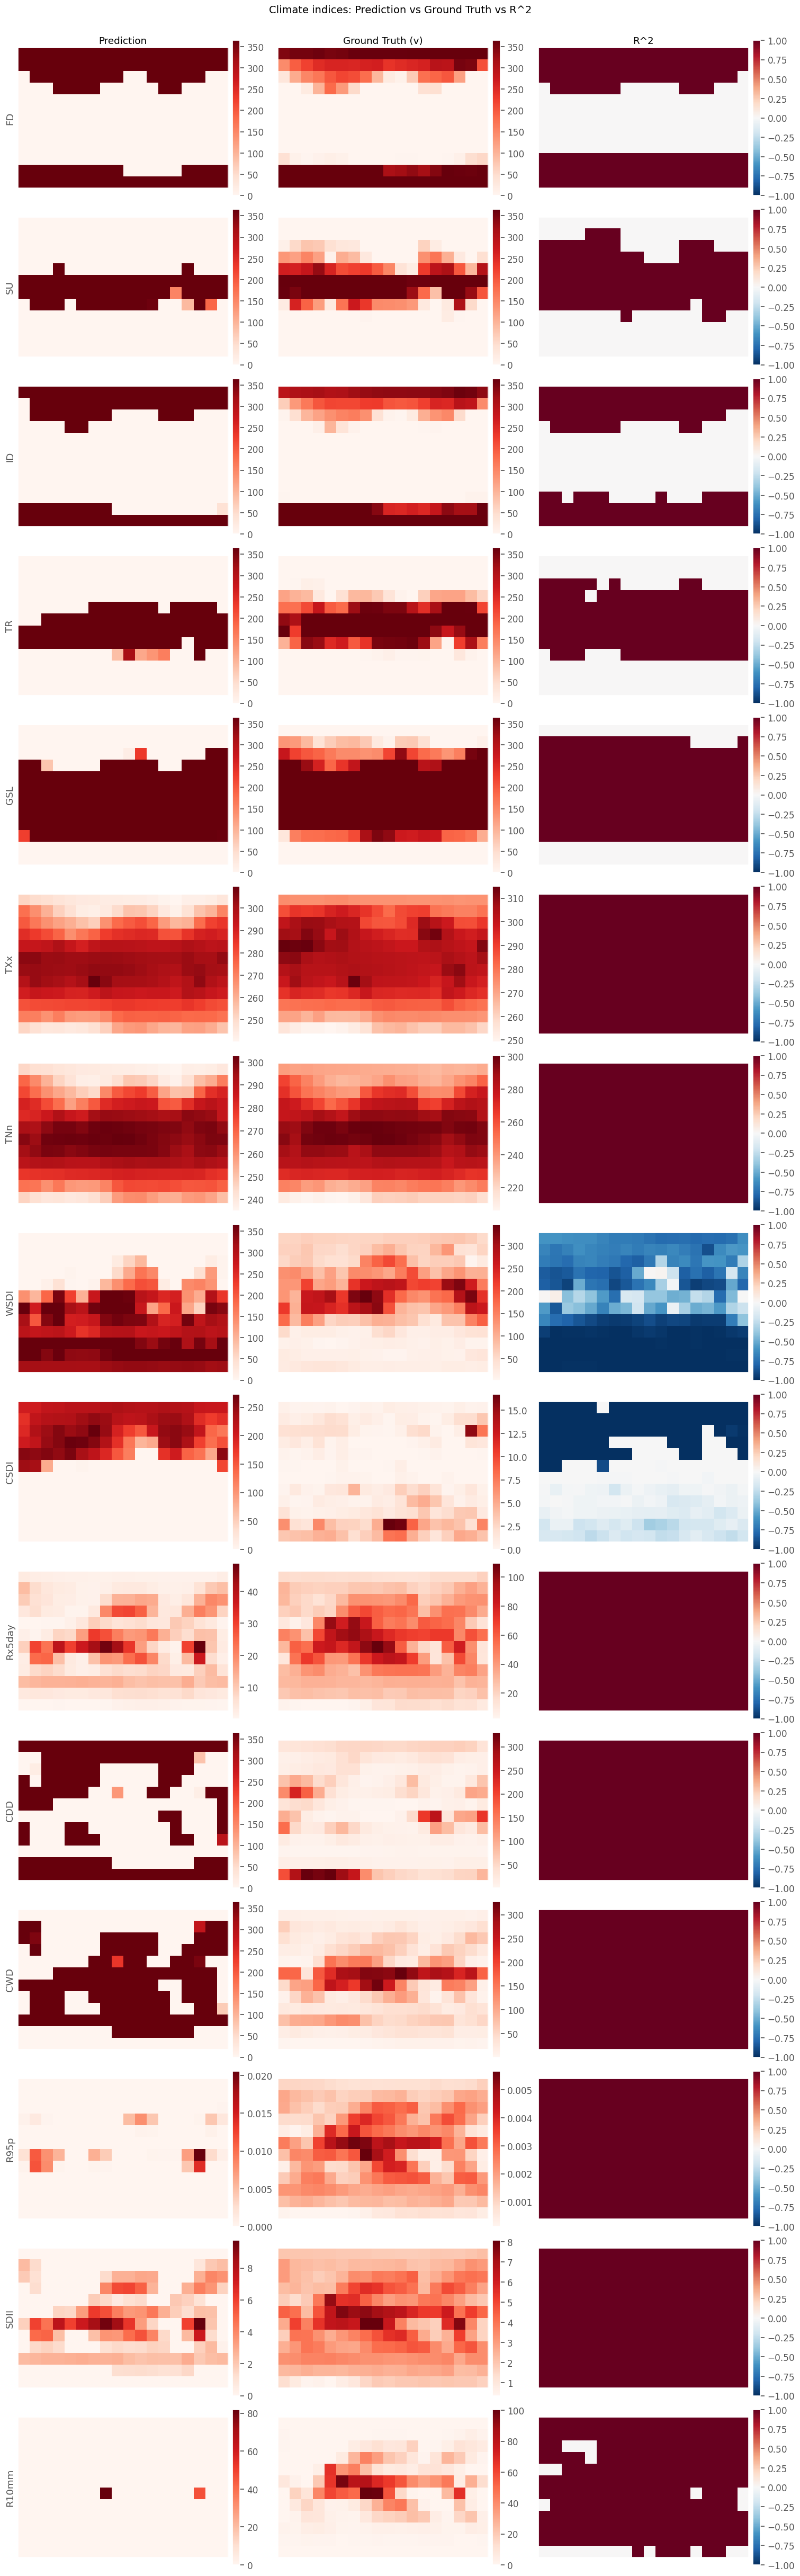

In [11]:
from src.metrics import pixel_wise_nr2
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

def _to_2d(da):
    out = da
    if "forcing_scenario" in out.dims:
        out = out.isel(forcing_scenario=0, drop=True)
    if "time" in out.dims:
        out = out.mean("time")
    return out.squeeze()


def plot_pred_truth_r2_grid(pred_ds, truth_ds, r2_ds, title):
    variables = [v for v in truth_ds.data_vars]
    n_rows = len(variables)
    if n_rows == 0:
        raise ValueError(f"No overlapping variables to plot for {title}")

    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 3.2 * n_rows), constrained_layout=True)
    if n_rows == 1:
        axes = np.array([axes])

    r2_stack = np.stack([_to_2d(r2_ds[v]).values for v in variables], axis=0)
    # r2_absmax = _finite_absmax(r2_stack, default=1.0)

    for i, var in enumerate(variables):
        pred_2d = _to_2d(pred_ds[var])
        truth_2d = _to_2d(truth_ds[var])
        r2_2d = _to_2d(r2_ds[var])

        # RdBu_r => negative values are blue, positive values are red.
        im_pred = axes[i, 0].imshow(pred_2d.values, cmap='Reds', origin="lower")
        im_truth = axes[i, 1].imshow(truth_2d.values, cmap='Reds', origin="lower")
        im_r2 = axes[i, 2].imshow(r2_2d.values, cmap='RdBu_r', vmin=-1, vmax=1, origin="lower")

        axes[i, 0].set_ylabel(var)
        for j in range(3):
            axes[i, j].set_xticks([])
            axes[i, j].set_yticks([])

        if i == 0:
            axes[i, 0].set_title("Prediction")
            axes[i, 1].set_title("Ground Truth (v)")
            axes[i, 2].set_title("R^2")

        fig.colorbar(im_pred, ax=axes[i, 0], fraction=0.046, pad=0.02)
        fig.colorbar(im_truth, ax=axes[i, 1], fraction=0.046, pad=0.02)
        fig.colorbar(im_r2, ax=axes[i, 2], fraction=0.046, pad=0.02)

    fig.suptitle(title, y=1.01, fontsize=14)
    plt.show()


r2_indices = pixel_wise_nr2(indices_pred, indices_v.sel(forcing_scenario='ssp585'), dim="time")


plot_pred_truth_r2_grid(
    pred_ds=indices_pred,
    truth_ds=indices_v,
    r2_ds=r2_indices,
    title="Climate indices: Prediction vs Ground Truth vs R^2"
)

In [12]:
save_dir = Path(f"results_{DATA_VERSION}/{model_type}_visuals")
emulator.visualize(
    y_pred,
    indices_pred, 
    save_dir,
    variables_to_plot={'y': ['tas', 'tasmax', 'tasmin', 'pr', 'huss', 'psl', 'sfcWind'], 
                       'indices': ['FD', 'SU', 'ID', 'TR', 'GSL', 'CDD', 'CWD', 'SDII', 'R10mm', 'R95p', 'Rx5day', 'TXx', 'TNn', 'WSDI', 'CSDI']},
    time_index=50,
    lat=40.0,
    lon=-95.0
)
print(f"Visualizations saved to {save_dir}")

2026-03-09 17:49:37,718 - src.models.emulator - INFO - Visualizing results...
2026-03-09 17:49:38,093 - src.visualization.utils - INFO - Saved plot to results_lite/lps_visuals/result_map_tas_2015-02-20.png
2026-03-09 17:49:38,257 - src.visualization.utils - INFO - Saved plot to results_lite/lps_visuals/result_timeseries_tas_40.0_-95.0.png
2026-03-09 17:49:38,585 - src.visualization.utils - INFO - Saved plot to results_lite/lps_visuals/result_map_tasmax_2015-02-20.png
2026-03-09 17:49:39,133 - src.visualization.utils - INFO - Saved plot to results_lite/lps_visuals/result_timeseries_tasmax_40.0_-95.0.png
2026-03-09 17:49:39,477 - src.visualization.utils - INFO - Saved plot to results_lite/lps_visuals/result_map_tasmin_2015-02-20.png
2026-03-09 17:49:39,629 - src.visualization.utils - INFO - Saved plot to results_lite/lps_visuals/result_timeseries_tasmin_40.0_-95.0.png
2026-03-09 17:49:39,951 - src.visualization.utils - INFO - Saved plot to results_lite/lps_visuals/result_map_pr_2015-02-2

## Suggested challenge branches

- **Track A (ML):** try `max_epochs=5`, then compare convergence and output quality.
- **Track B (science):** inspect variables/regions with strongest mismatch and propose a hypothesis.
- Keep notes of what changed, why, and what improved.